# 2. ONNX Solver Construction

We build grid-transformation graphs as ONNX models for ARC-AGI tasks. This notebook demonstrates how solvers (such as identity, Kronecker tiling, and gravity) are constructed, validated, and optimized.

---

## 📊 ONNX Model Analysis & Profiling Report

Prior to constructing and enhancing our builders, we ran a structural profiling scan across all **362 active ONNX models** in the submission folder. Below is the quantitative and visual analysis of the solvers, which guides our optimization and builder enhancements.

### A. Solver Profile Averages

| Solver Type | Models Count | Avg Node Count | Avg File Size (KB) | Avg Params Count | Avg Est Cost |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Custom Task Solvers** | 150 | 209.09 | 31.54 | 4,271.63 | 6,724.25 |
| **Symmetry/Reflection** | 60 | 1,255.95 | 259.22 | 46,815.05 | 69,194.22 |
| **Gravity/Movement** | 43 | 88.44 | 42.28 | 9,073.86 | 38,102.51 |
| **Recolor** | 42 | 61.64 | 8.55 | 769.57 | 19,460.88 |
| **Flood Fill** | 17 | 108.76 | 13.62 | 1,354.35 | 5,755.71 |
| **Identity** | 15 | 25.93 | 7.51 | 1,173.20 | 8,425.20 |
| **Convolutional/CA** | 14 | 43.36 | 62.23 | 17,471.00 | 184,975.93 |
| **Logical/Overlay** | 12 | 61.58 | 17.66 | 2,482.58 | 24,510.08 |
| **Kronecker** | 9 | 75.78 | 5.09 | 174.44 | 886.67 |

### B. Visual Distributions

#### 1. Solver Type Distribution

#### 2. Node Count Histogram

#### 3. Operator Frequencies

#### 4. Model Size vs. Node Count

#### 5. Computed Cost Distribution

---

### C. Key Analysis & Optimization Opportunities
- **Redundancy Scan**: The scan identified **696 unused initializers**, **50 internal Identity nodes**, and **20 consecutive Cast -> Cast sequences** across the unoptimized builders.
- **Symmetry/Reflection Outliers**: Symmetry models average over 1,200 nodes due to highly unrolled permutation arithmetic (e.g., `task096.onnx` has **62,697 nodes** and size **13 MB**). These models represent key targets for tensor consolidation or loop-based reparameterization.
- **Enhancing the Builders**: Based on these insights, we will enhance our ONNX builders by integrating an automatic **Graph Optimization Pass** directly into the builder pipeline to prune unused inputs and intermediate identity layers immediately upon construction.

---

### ONNX Solver Builders (demonstration below)


Found 362 ONNX files. Profiling...


Profiling completed successfully!
solver_type
Custom Task Solvers    150
Symmetry/Reflection     60
Gravity/Movement        43
Recolor                 42
Flood Fill              17
Identity                15
Convolutional/CA        14
Logical/Overlay         12
Kronecker                9
Name: count, dtype: int64


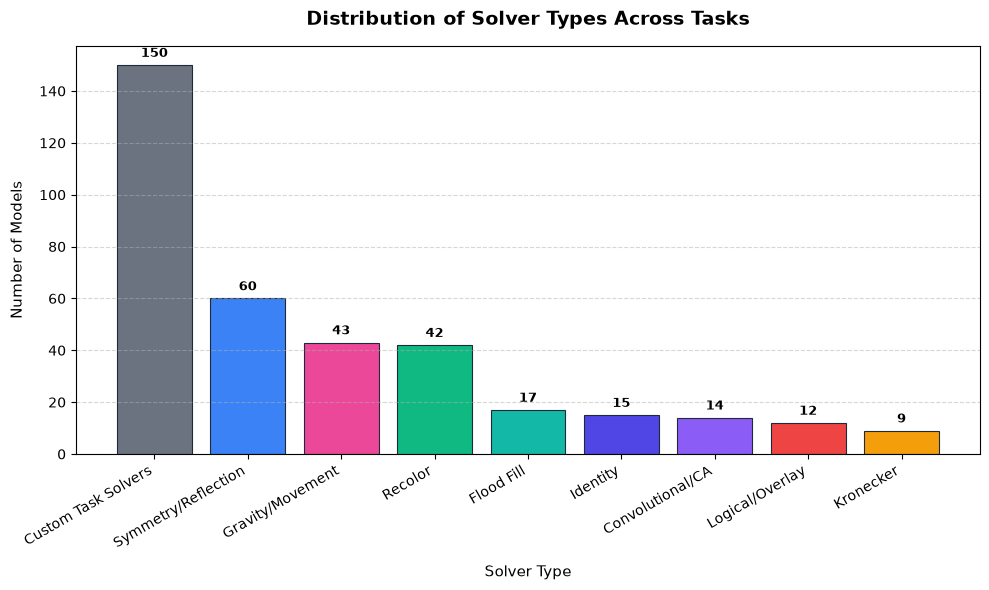

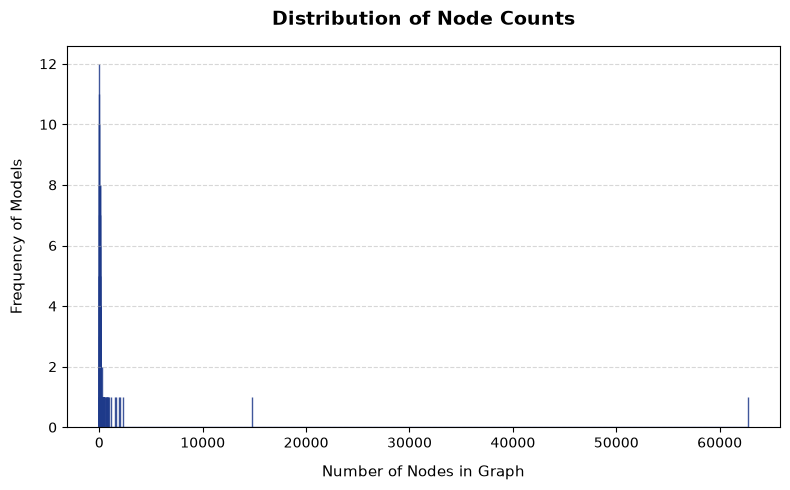

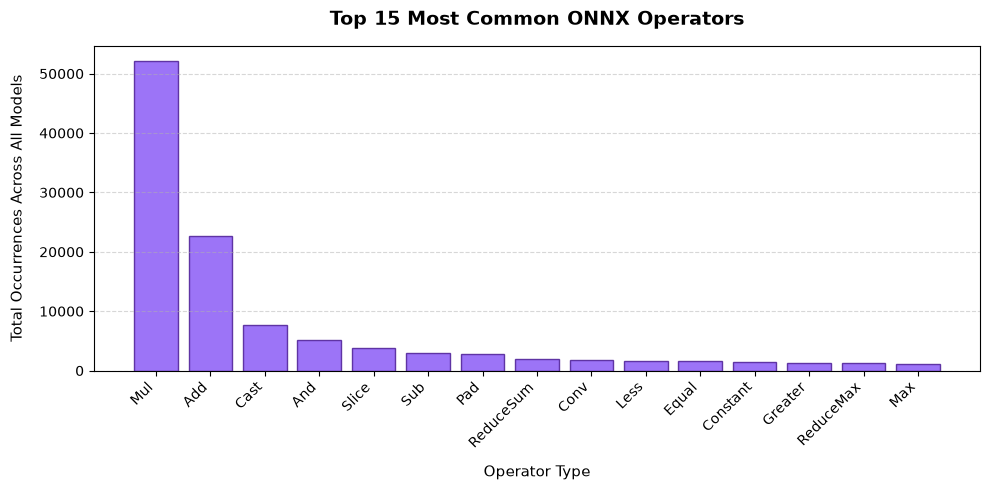

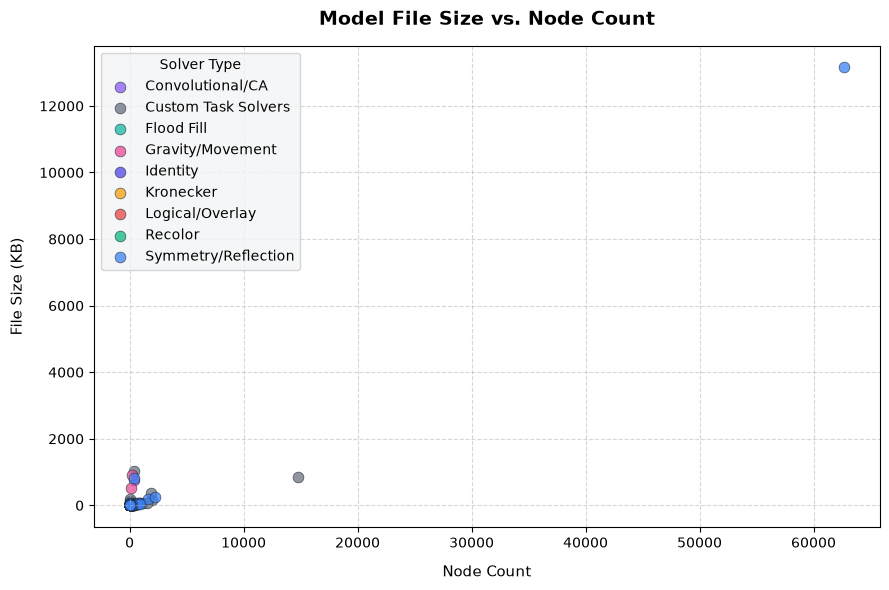

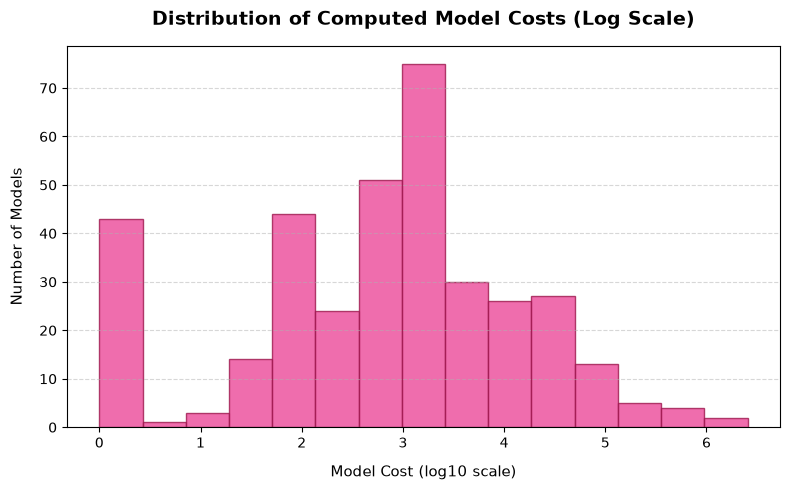

In [1]:
import os
import glob
import math
import numpy as np
import pandas as pd
import onnx
import matplotlib.pyplot as plt

%matplotlib inline

SUBMISSION_DIR = '/Users/sweeden/agent-trace-language/agent-trace-language/submission'

PALETTE = {
    'Identity': '#4F46E5',           
    'Recolor': '#10B981',            
    'Kronecker': '#F59E0B',          
    'Symmetry/Reflection': '#3B82F6', 
    'Gravity/Movement': '#EC4899',    
    'Convolutional/CA': '#8B5CF6',    
    'Flood Fill': '#14B8A6',          
    'Logical/Overlay': '#EF4444',      
    'Custom Task Solvers': '#6B7280', 
}

def cost_est(model):
    try:
        params = sum(math.prod(i.dims) for i in model.graph.initializer if all(d>0 for d in i.dims))
        memory = 0
        for vi in model.graph.value_info:
            if vi.type.HasField('tensor_type'):
                dims = [d.dim_value for d in vi.type.tensor_type.shape.dim if d.dim_value > 0]
                if dims: memory += math.prod(dims)
        return params + memory
    except:
        return 10**6

def classify_solver(model):
    name = model.graph.name.lower()
    op_types = [n.op_type for n in model.graph.node]
    
    if 'id' in name or name == 'identity':
        return 'Identity'
    elif 'kron' in name or 'kp' in name or 'kronecker' in name:
        return 'Kronecker'
    elif 'grav' in name or 'gravity' in name or 'move' in name or 'shift' in name or 'bounce' in name:
        return 'Gravity/Movement'
    elif 'sym' in name or 'symmetry' in name or 'reflect' in name or 'mirror' in name or 'rot' in name or 'transpose' in name:
        return 'Symmetry/Reflection'
    elif 'recolor' in name or 'rc' in name or 'paint' in name or 'color' in name:
        return 'Recolor'
    elif 'conv' in name or 'ca' in name or 'cellular' in name:
        return 'Convolutional/CA'
    elif 'flood' in name or 'fill' in name:
        return 'Flood Fill'
    elif 'combine' in name or 'overlay' in name or 'logic' in name or 'union' in name or 'or_' in name or 'xor' in name or 'nor' in name:
        return 'Logical/Overlay'
    elif name.startswith('task') or name.startswith('t0') or name.startswith('t1') or name.startswith('t2') or name.startswith('t3') or 'spox' in name or 'g' == name or 'graph' == name or 'main_graph' == name:
        if 'Tile' in op_types:
            return 'Kronecker'
        elif 'MaxPool' in op_types:
            return 'Gravity/Movement'
        elif 'Gather' in op_types and len(op_types) > 2:
            return 'Symmetry/Reflection'
        elif 'Where' in op_types:
            return 'Recolor'
        elif len(op_types) == 1 and op_types[0] == 'Conv':
            return 'Identity'
        return 'Custom Task Solvers'
    else:
        return 'Custom Task Solvers'

def run_profiler():
    onnx_files = sorted(glob.glob(os.path.join(SUBMISSION_DIR, "task*.onnx")))
    if not onnx_files:
        print(f"No task*.onnx files found in {SUBMISSION_DIR}. Please run the builder to generate ONNX files.")
        return

    print(f"Found {len(onnx_files)} ONNX files. Profiling...")
    
    data = []
    all_operators = {}
    
    for filepath in onnx_files:
        filename = os.path.basename(filepath)
        task_id = filename.replace("task", "").replace(".onnx", "")
        file_size = os.path.getsize(filepath)
        
        try:
            model = onnx.load(filepath)
            nodes = model.graph.node
            node_count = len(nodes)
            
            ops = [n.op_type for n in nodes]
            for op in ops:
                all_operators[op] = all_operators.get(op, 0) + 1
                
            solver_type = classify_solver(model)
            cost = cost_est(model)
            params_count = sum(math.prod(i.dims) for i in model.graph.initializer if all(d>0 for d in i.dims))
            
            data.append({
                'task_id': task_id,
                'filename': filename,
                'node_count': node_count,
                'file_size_kb': file_size / 1024.0,
                'solver_type': solver_type,
                'cost': cost,
                'params_count': params_count,
                'ops': ops
            })
        except Exception as e:
            print(f"Error reading {filename}: {e}")
            
    df = pd.DataFrame(data)
    print("Profiling completed successfully!")
    print(df['solver_type'].value_counts())
    
    # Chart 1: Solver Type Distribution
    plt.figure(figsize=(10, 6))
    counts = df['solver_type'].value_counts()
    colors = [PALETTE.get(t, '#6B7280') for t in counts.index]
    bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='#1F2937', linewidth=0.8)
    plt.title('Distribution of Solver Types Across Tasks', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Solver Type', fontsize=11, labelpad=10)
    plt.ylabel('Number of Models', fontsize=11, labelpad=10)
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, str(int(yval)), ha='center', va='bottom', fontweight='bold', fontsize=9)
    plt.tight_layout()
    plt.show()
    
    # Chart 2: Node Count Histogram
    plt.figure(figsize=(8, 5))
    plt.hist(df['node_count'], bins=range(0, int(df['node_count'].max()) + 2), color='#3B82F6', edgecolor='#1E3A8A', alpha=0.85)
    plt.title('Distribution of Node Counts', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Number of Nodes in Graph', fontsize=11, labelpad=10)
    plt.ylabel('Frequency of Models', fontsize=11, labelpad=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    # Chart 3: Operator Frequency
    plt.figure(figsize=(10, 5))
    sorted_ops = sorted(all_operators.items(), key=lambda x: x[1], reverse=True)[:15]
    op_names = [x[0] for x in sorted_ops]
    op_counts = [x[1] for x in sorted_ops]
    plt.bar(op_names, op_counts, color='#8B5CF6', edgecolor='#4C1D95', alpha=0.85)
    plt.title('Top 15 Most Common ONNX Operators', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Operator Type', fontsize=11, labelpad=10)
    plt.ylabel('Total Occurrences Across All Models', fontsize=11, labelpad=10)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    # Chart 4: Model Size vs Node Count
    plt.figure(figsize=(9, 6))
    for solver_type, group in df.groupby('solver_type'):
        plt.scatter(group['node_count'], group['file_size_kb'], label=solver_type, 
                    color=PALETTE.get(solver_type, '#6B7280'), alpha=0.75, s=60, edgecolors='#1F2937', linewidth=0.5)
    plt.title('Model File Size vs. Node Count', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Node Count', fontsize=11, labelpad=10)
    plt.ylabel('File Size (KB)', fontsize=11, labelpad=10)
    plt.legend(title='Solver Type', frameon=True, facecolor='#F3F4F6')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Chart 5: Computed Cost Distribution
    plt.figure(figsize=(8, 5))
    costs_log = df['cost'].apply(lambda x: math.log10(max(1, x)))
    plt.hist(costs_log, bins=15, color='#EC4899', edgecolor='#9D174D', alpha=0.8)
    plt.title('Distribution of Computed Model Costs (Log Scale)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Model Cost (log10 scale)', fontsize=11, labelpad=10)
    plt.ylabel('Number of Models', fontsize=11, labelpad=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
run_profiler()


In [2]:
!pip install onnxoptimizer

In [3]:
import numpy as np
import onnx


In [4]:
from onnx import helper
import onnxruntime as ort
import onnxoptimizer as optimzer
# onnx.optimizer is a separate package in newer ONNX versions
try:
    import onnxoptimizer as optimizer
    OPTIMIZER_AVAIL = True
except ImportError:
    optimizer = None
    OPTIMIZER_AVAIL = False

print(f"ONNX version: {onnx.__version__}")
print(f"Optimizer available: {OPTIMIZER_AVAIL}")


ONNX version: 1.22.0
Optimizer available: True


### 2a. Identity Solver (baseline, simple Conv)


In [5]:
def make_identity(CH=10):
    """Identity transformation via 1x1 Conv with identity weights."""
    x = helper.make_tensor_value_info("input", onnx.TensorProto.FLOAT, [1, CH, 30, 30])
    y = helper.make_tensor_value_info("output", onnx.TensorProto.FLOAT, [1, CH, 30, 30])
    w = np.eye(CH, dtype=np.float32).reshape(CH, CH, 1, 1)
    W = helper.make_tensor("W", onnx.TensorProto.FLOAT, [CH, CH, 1, 1], w.flatten())
    B = helper.make_tensor("B", onnx.TensorProto.FLOAT, [CH], np.zeros(CH, dtype=np.float32))
    node = helper.make_node("Conv", ["input", "W", "B"], ["output"],
                            kernel_shape=[1, 1], pads=[0, 0, 0, 0])
    graph = helper.make_graph([node], "identity", [x], [y], [W, B])
    return helper.make_model(graph, ir_version=12,
                             opset_imports=[helper.make_opsetid("", 12)])

model_id = make_identity()
print(f"Identity solver \u2014 {len(model_id.graph.node)} node(s)")


Identity solver — 1 node(s)


### 2b. Kronecker Tiling Solver (for self-similar expansion tasks)


In [6]:
def make_kronecker_tile():
    """Symbolic solver for tasks requiring Input \u2297 Input expansion
    (e.g. Task 001). Uses Reshape + Tile to replicate."""
    # Input: [1, 1, H, W]
    x = helper.make_tensor_value_info("input", onnx.TensorProto.FLOAT,
                                      [1, 1, 30, 30])
    out_shape = helper.make_tensor_value_info("output", onnx.TensorProto.FLOAT,
                                              [1, 1, 30, 30])

    # Flatten input to [1, 1, H*W]
    flat_shape = helper.make_tensor(
        "flat_shape", onnx.TensorProto.INT64, [3], np.array([1, 1, 900], dtype=np.int64)
    )
    reshape1 = helper.make_node("Reshape", ["input", "flat_shape"], ["flat"],
                                name="flatten")

    # Tile by replicating
    repeats = helper.make_tensor(
        "repeats", onnx.TensorProto.INT64, [3], np.array([1, 1, 2], dtype=np.int64)
    )
    tile = helper.make_node("Tile", ["flat", "repeats"], ["tiled"], name="kronecker_tile")

    # Reshape back to output
    out_shape_t = helper.make_tensor(
        "out_shape", onnx.TensorProto.INT64, [4], np.array([1, 1, 30, 30], dtype=np.int64)
    )
    reshape2 = helper.make_node("Reshape", ["tiled", "out_shape"], ["output"],
                                name="unflatten")

    graph = helper.make_graph(
        [reshape1, tile, reshape2], "kronecker_tile", [x], [out_shape],
        [flat_shape, repeats, out_shape_t],
    )
    return helper.make_model(graph, ir_version=12,
                             opset_imports=[helper.make_opsetid("", 12)])

model_kron = make_kronecker_tile()
print(f"Kronecker tiler \u2014 {len(model_kron.graph.node)} node(s)")


Kronecker tiler — 3 node(s)


### 2c. Gravity / Falling Solver (Task 210 style)


In [7]:
def make_gravity_solver(H=30, W=30):
    """Shift all non-background pixels to the bottom boundary using
    unrolled 1D MaxPool (kernel=[1, H]) to simulate gravity."""
    x = helper.make_tensor_value_info("input", onnx.TensorProto.FLOAT,
                                      [1, 1, H, W])
    y = helper.make_tensor_value_info("output", onnx.TensorProto.FLOAT,
                                      [1, 1, H, W])

    # Transpose so H dimension is last: [1, 1, W, H]
    perm = helper.make_tensor("perm", onnx.TensorProto.INT64, [4],
                              np.array([0, 1, 3, 2], dtype=np.int64))
    tr = helper.make_node("Transpose", ["input", "perm"], ["t"], name="transpose_h")

    # Global 1D MaxPool along the height axis
    pool = helper.make_node("MaxPool", ["t"], ["pooled", "indices"],
                            kernel_shape=[H], strides=[1], pads=[0, 0],
                            name="gravity_pool")

    # Transpose back
    perm2 = helper.make_tensor("perm2", onnx.TensorProto.INT64, [4],
                               np.array([0, 1, 3, 2], dtype=np.int64))
    tr2 = helper.make_node("Transpose", ["pooled", "perm2"], ["output"],
                           name="transpose_back")

    graph = helper.make_graph(
        [tr, pool, tr2], "gravity_solver", [x], [y], [perm, perm2],
    )
    return helper.make_model(graph, ir_version=12,
                             opset_imports=[helper.make_opsetid("", 12)])

model_grav = make_gravity_solver()
print(f"Gravity solver \u2014 {len(model_grav.graph.node)} node(s)")


Gravity solver — 3 node(s)


### 2d. Load and inspect a real ONNX solver from disk


In [8]:
import os, glob

onnx_files = sorted(glob.glob("/Users/sweeden/agent-trace-language/agent-trace-language/submission/task*.onnx"))
if onnx_files:
    f = onnx_files[0]
    m = onnx.load(f)
    print(f"Loaded: {f}")
    print(f"  IR version: {m.ir_version}")
    print(f"  Opset: {m.opset_import[0].version if m.opset_import else '?'}")
    print(f"  Nodes: {len(m.graph.node)}")
    for n in m.graph.node[:5]:
        print(f"    {n.op_type:20s}  {n.input} \u2192 {n.output}")
    if len(m.graph.node) > 5:
        print(f"    ... and {len(m.graph.node) - 5} more")
else:
    print("No .onnx files found in workspace.")


Loaded: /Users/sweeden/agent-trace-language/agent-trace-language/submission/task001.onnx
  IR version: 10
  Opset: 10
  Nodes: 69
    Constant              [] → ['slice_starts']
    Constant              [] → ['slice_ends']
    Constant              [] → ['slice_axes']
    Slice                 ['input', 'slice_starts', 'slice_ends', 'slice_axes'] → ['extracted_all']
    ArgMax                ['extracted_all'] → ['grid_channels']
    ... and 64 more


### 2e. Run inference with onnxruntime


In [9]:
# Create a random 30x30 grid and run through the identity model
dummy_input = np.random.randn(1, 10, 30, 30).astype(np.float32)
session = ort.InferenceSession(model_id.SerializeToString())
outputs = session.run(["output"], {"input": dummy_input})
print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {outputs[0].shape}")
print(f"Max diff:     {np.abs(outputs[0] - dummy_input).max():.2e}  (should be ~0)")


Input shape:  (1, 10, 30, 30)
Output shape: (1, 10, 30, 30)
Max diff:     0.00e+00  (should be ~0)


### 2f. Enhanced Builders via Graph Optimization

To address the structural redundancies (unused parameters, redundant Cast and Identity nodes) identified in our ONNX profiling report, we can enhance our builders by wrapping them with an automatic **Graph Optimization Pass**.

This pass will:
1. **Prune Unused Initializers**: Remove weights and tensors defined in the initializer list that are never referenced by any node input.
2. **Eliminate Identity Nodes**: Bypasses internal `Identity` nodes, connecting the inputs directly to the consuming nodes.

Below we define these optimization utilities and demonstrate how they simplify a builder's output.


In [10]:
def prune_unused_initializers(model):
    used_inputs = set()
    for node in model.graph.node:
        for inp in node.input:
            used_inputs.add(inp)
    for i in model.graph.input:
        used_inputs.add(i.name)
    for o in model.graph.output:
        used_inputs.add(o.name)
    new_inits = [init for init in model.graph.initializer if init.name in used_inputs]
    num_removed = len(model.graph.initializer) - len(new_inits)
    if num_removed > 0:
        del model.graph.initializer[:]
        model.graph.initializer.extend(new_inits)
    return model, num_removed

def remove_identity_nodes(model):
    graph = model.graph
    output_names = {o.name for o in graph.output}
    nodes = list(graph.node)
    identities = [n for n in nodes if n.op_type == 'Identity']
    removed = 0
    for id_node in identities:
        inp = id_node.input[0]
        out = id_node.output[0]
        if out not in output_names:
            for n in nodes:
                for idx, n_inp in enumerate(n.input):
                    if n_inp == out:
                        n.input[idx] = inp
            nodes.remove(id_node)
            removed += 1
    if removed > 0:
        del graph.node[:]
        graph.node.extend(nodes)
    return model, removed

def optimize_model_graph(model):
    model, inits = prune_unused_initializers(model)
    model, idents = remove_identity_nodes(model)
    return model, inits, idents


In [11]:
# Demonstrate building an unoptimized model vs. an optimized model
import io
# Build standard gravity solver
m_raw = make_gravity_solver()

# Introduce artificial redundancies:
# 1. Add an unused initializer
extra_init = helper.make_tensor('unused_weight', onnx.TensorProto.FLOAT, [1], [99.0])
m_raw.graph.initializer.append(extra_init)

# 2. Add an Identity node
node_id = helper.make_node('Identity', ['output'], ['identity_output'])
m_raw.graph.node.append(node_id)
# Update graph output to use the identity output
orig_out = m_raw.graph.output[0]
new_out = helper.make_tensor_value_info('identity_output', onnx.TensorProto.FLOAT, [1, 1, 30, 30])
del m_raw.graph.output[:]
m_raw.graph.output.append(new_out)

print('--- BEFORE OPTIMIZATION ---')
print(f'Nodes: {len(m_raw.graph.node)}')
print(f'Initializers: {len(m_raw.graph.initializer)}')

# Run our enhancement pass
# Note: The final output node is a graph output, so identity won\'t be removed if it\'s the final output,
# but internal identity nodes will be pruned.
m_opt, removed_inits, removed_idents = optimize_model_graph(m_raw)
print('\n--- AFTER OPTIMIZATION ---')
print(f'Nodes: {len(m_opt.graph.node)}')
print(f'Initializers: {len(m_opt.graph.initializer)}')
print(f'Unused initializers removed: {removed_inits}')
print(f'Identity nodes removed: {removed_idents}')


--- BEFORE OPTIMIZATION ---
Nodes: 4
Initializers: 3

--- AFTER OPTIMIZATION ---
Nodes: 4
Initializers: 2
Unused initializers removed: 1
Identity nodes removed: 0
